<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/piste2bis_rg_conductances_cell4_colab_CHECKPOINT_DRIVE_N50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Piste 2bis — Récurrence RG des conductances cell-4 → \(Z_{th}\), \(\Delta Z\), \(\kappa/a\)

**Destination : Google Colab.**  
**Mode : Codex + autotests.**

Ce notebook complète :

- **Piste 1** : extraction numérique de \(d_s^{eff}(Z)\) depuis la trace de chaleur sur graphes cell-4 multiplex ;
- **Piste 2** : fermeture mean-field Allen–Cahn calibrée sur le crossover spectral.

Ici, la question est plus forte : peut-on obtenir directement les paramètres effectifs

\[
Z_{th}, \qquad \Delta Z, \qquad \frac{\kappa}{a}=\frac{\Delta Z^2}{2}
\]

à partir d'une **récurrence RG des conductances cell-4**, sans ajuster directement la trace de chaleur ?

Le modèle utilisé reste volontairement minimal : support cell-4 4-voisins, micro-contacts inter-couches à seuils locaux \(\Theta_e\), activation dure \(Z\geq\Theta_e\), coarse-graining \(2\times2\), puis extraction d'un ordre paramètre de conductance RG.

**Lecture reviewer-safe :** si le contrôle négatif reste constant et si le cas cell-4 multiplex favorise une sigmoïde avec des paramètres proches de la Piste 1, alors la Piste 2bis fournit une dérivation opérationnelle du front mean-field à partir des conductances.
---

### Version renforcée — checkpoint Drive / publication sweep

Cette version conserve la logique originale du notebook **Piste 2bis — RG recurrence of cell-4 conductances** et ajoute :

- `RUN_FAST = True` ;
- `RUN_PUBLICATION_SWEEP = True` ;
- `n_realizations = 50` dans la configuration principale ;
- checkpoint par réalisation vers Google Drive ;
- reprise automatique des scans interrompus ;
- export ZIP final persistant dans Drive quand le montage est disponible.

Le checkpoint est conçu pour les relances Colab : si un run est interrompu, le notebook recharge les réalisations déjà exportées et ne calcule que les réalisations manquantes.


In [1]:

# ============================================================
# Cellule 1 — Imports, configuration globale Colab + Drive
# ============================================================
import os, json, math, time, warnings, shutil, hashlib
from dataclasses import dataclass, asdict, replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# Modes demandés pour la version publication/checkpoint
# ------------------------------------------------------------
RUN_FAST = True
RUN_PUBLICATION_SWEEP = True

# ------------------------------------------------------------
# Persistance Colab / Google Drive
# ------------------------------------------------------------
USE_GOOGLE_DRIVE = True
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/ROSG_exports/piste2bis_rg_conductances_cell4_N50'
LOCAL_OUTDIR = Path('/content/piste2bis_rg_conductances_cell4_N50')

DRIVE_AVAILABLE = False
if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        DRIVE_AVAILABLE = Path('/content/drive/MyDrive').exists()
    except Exception as exc:
        DRIVE_AVAILABLE = False
        print('[drive] Google Drive unavailable; falling back to local /content output.')
        print('[drive] reason:', repr(exc))

if DRIVE_AVAILABLE:
    OUTDIR = Path(DRIVE_PROJECT_DIR)
else:
    OUTDIR = LOCAL_OUTDIR

OUTDIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = OUTDIR / '_checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RUN_METADATA = {
    'run_fast': RUN_FAST,
    'run_publication_sweep': RUN_PUBLICATION_SWEEP,
    'drive_available': DRIVE_AVAILABLE,
    'outdir': str(OUTDIR),
    'checkpoint_dir': str(CHECKPOINT_DIR),
    'created_at_unix': time.time(),
}
with open(OUTDIR / 'RUN_METADATA.json', 'w', encoding='utf-8') as f:
    json.dump(RUN_METADATA, f, indent=2, ensure_ascii=False)

print('Output directory:', OUTDIR)
print('Checkpoint directory:', CHECKPOINT_DIR)
print('Google Drive available:', DRIVE_AVAILABLE)
print('RUN_FAST:', RUN_FAST)
print('RUN_PUBLICATION_SWEEP:', RUN_PUBLICATION_SWEEP)
print('NumPy:', np.__version__)


Mounted at /content/drive
Output directory: /content/drive/MyDrive/ROSG_exports/piste2bis_rg_conductances_cell4_N50
Checkpoint directory: /content/drive/MyDrive/ROSG_exports/piste2bis_rg_conductances_cell4_N50/_checkpoints
Google Drive available: True
RUN_FAST: True
RUN_PUBLICATION_SWEEP: True
NumPy: 2.0.2


In [2]:
# ============================================================
# Cellule 2 — Paramètres de référence Piste 1 / Piste 2
# ============================================================
PISTE1 = {
    'Z_th_mean': 1.7310104905091812,
    'Z_th_std': 0.16778406793494766,
    'Delta_Z_mean': 1.0495786387231472,
    'Delta_Z_std': 0.37340239196276837,
    'd_uv_mean': 2.066,
    'd_ir_mean': 2.6881850228422044,
    'd_ir_std': 0.09382824366974964,
    't_planck_s': 5.391247e-44,
}
print(json.dumps(PISTE1, indent=2))


{
  "Z_th_mean": 1.7310104905091812,
  "Z_th_std": 0.16778406793494766,
  "Delta_Z_mean": 1.0495786387231472,
  "Delta_Z_std": 0.37340239196276837,
  "d_uv_mean": 2.066,
  "d_ir_mean": 2.6881850228422044,
  "d_ir_std": 0.09382824366974964,
  "t_planck_s": 5.391247e-44
}


In [3]:
# ============================================================
# Cellule 3 — Configuration du modèle RG cell-4
# ============================================================
@dataclass
class RGConfig:
    L: int = 16
    layers: int = 8
    torus_xy: bool = True
    torus_layers: bool = True
    z_min: float = -1.5
    z_max: float = 5.5
    n_z: int = 21
    theta_center: float = 1.85
    theta_jitter: float = 0.85
    hierarchical_noise: float = 0.35
    random_seed: int = 202604
    w_plane: float = 1.0
    w_vertical_hi: float = 1.0
    n_rg_steps: int = 3
    activation_cutoff: float = 0.50
    n_realizations: int = 50
    smooth_profile: bool = True
    savgol_window: int = 7
    savgol_poly: int = 2
    d_uv_ref: float = PISTE1['d_uv_mean']
    d_ir_ref: float = PISTE1['d_ir_mean']

cfg = RGConfig()
print(cfg)


RGConfig(L=16, layers=8, torus_xy=True, torus_layers=True, z_min=-1.5, z_max=5.5, n_z=21, theta_center=1.85, theta_jitter=0.85, hierarchical_noise=0.35, random_seed=202604, w_plane=1.0, w_vertical_hi=1.0, n_rg_steps=3, activation_cutoff=0.5, n_realizations=50, smooth_profile=True, savgol_window=7, savgol_poly=2, d_uv_ref=2.066, d_ir_ref=2.6881850228422044)


## Principe de la récurrence RG

Pour chaque valeur de \(Z\), les liens verticaux inter-couches sont activés par une règle locale dure :

\[
w_e(Z)=w_{\perp}\,\mathbf{1}_{Z\geq \Theta_e}.
\]

Les seuils \(\Theta_e\) sont distribués autour d'un centre \(\Theta_0\), avec une composante hiérarchique simulant l'hétérogénéité des micro-contacts cell-4.

Lors d'une décimation \(2\times2\), les conductances verticales d'un bloc sont agrégées. Un lien vertical coarse-grained est considéré actif si sa fraction de capacité dépasse un seuil de majorité :

\[
m_{\ell+1}(Z) = \mathcal{R}\big(m_{\ell}(Z); Z\big).
\]

Le profil final \(m_*(Z)\) est ensuite ajusté par :

\[
m_*(Z)\simeq \frac12\left[1+\tanh\left(\frac{Z-Z_{th}^{RG}}{\Delta Z_{RG}}\right)\right].
\]

Puis :

\[
\frac{\kappa}{a}=\frac{\Delta Z_{RG}^2}{2}.
\]


In [4]:
# ============================================================
# Cellule 4 — Fonctions de seuils hiérarchiques cell-4
# ============================================================
def _smooth_cell_noise(L, rng, amplitude=0.35):
    # Bruit hiérarchique simple par blocs 2^k, centré-réduit.
    noise = np.zeros((L, L), dtype=float)
    scales = [max(1, L//2), max(1, L//4), max(1, L//8), 1]
    weights = np.array([0.45, 0.30, 0.18, 0.07], dtype=float)
    weights = weights / weights.sum()
    for block, w in zip(scales, weights):
        coarse_shape = (math.ceil(L/block), math.ceil(L/block))
        coarse = rng.normal(0.0, 1.0, size=coarse_shape)
        expanded = np.repeat(np.repeat(coarse, block, axis=0), block, axis=1)[:L, :L]
        noise += w * expanded
    noise = (noise - noise.mean()) / (noise.std() + 1e-12)
    return amplitude * noise


def make_vertical_thresholds(cfg: RGConfig, realization_id=0):
    # Seuils Theta_e pour chaque lien vertical inter-couche.
    rng = np.random.default_rng(cfg.random_seed + 7919 * realization_id)
    n_v_layers = cfg.layers if cfg.torus_layers else cfg.layers - 1
    thresholds = np.empty((n_v_layers, cfg.L, cfg.L), dtype=float)
    for ell in range(n_v_layers):
        hnoise = _smooth_cell_noise(cfg.L, rng, cfg.hierarchical_noise)
        local = rng.normal(0.0, cfg.theta_jitter, size=(cfg.L, cfg.L))
        thresholds[ell] = cfg.theta_center + hnoise + local
    return thresholds

thr = make_vertical_thresholds(cfg, realization_id=0)
print('thresholds shape:', thr.shape, 'mean/std:', float(thr.mean()), float(thr.std()))


thresholds shape: (8, 16, 16) mean/std: 1.8888478744103245 0.9051090314206556


In [5]:

# ============================================================
# Cellule 5 — Décimation RG des conductances verticales + checkpoint Drive
# ============================================================
def vertical_activity_initial(thresholds, Z):
    return (Z >= thresholds).astype(float)


def block_reduce_activity(A, cutoff=0.5):
    # Coarse-graining spatial 2x2 par seuil de majorité.
    nvl, L, _ = A.shape
    assert L % 2 == 0, 'L must be divisible by 2 at each RG step.'
    A2 = A.reshape(nvl, L//2, 2, L//2, 2).mean(axis=(2,4))
    return (A2 >= cutoff).astype(float)


def conductance_rg_profile_for_Z(thresholds, Z, cfg: RGConfig):
    A = vertical_activity_initial(thresholds, Z)
    out = []
    for level in range(cfg.n_rg_steps + 1):
        m = float(A.mean()) if A.size else 0.0
        out.append({'rg_level': level, 'L_level': A.shape[1], 'm_active': m})
        if level < cfg.n_rg_steps:
            if A.shape[1] < 2:
                break
            A = block_reduce_activity(A, cfg.activation_cutoff)
    return out


import re

def _cfg_digest(cfg: RGConfig, tag='scan'):
    payload = {'tag': str(tag), **asdict(cfg)}
    raw = json.dumps(payload, sort_keys=True, default=str).encode('utf-8')
    return hashlib.sha256(raw).hexdigest()[:12]


def _checkpoint_paths(cfg: RGConfig, tag='scan'):
    safe_tag = re.sub(r'[^A-Za-z0-9_.-]+', '_', str(tag))
    digest = _cfg_digest(cfg, safe_tag)
    stem = f'{safe_tag}_{digest}'
    return {
        'stem': stem,
        'raw_csv': CHECKPOINT_DIR / f'{stem}_raw_partial.csv',
        'meta_json': CHECKPOINT_DIR / f'{stem}_checkpoint_meta.json',
        'done_txt': CHECKPOINT_DIR / f'{stem}_DONE.txt',
    }


def _load_checkpoint(cfg: RGConfig, tag='scan'):
    paths = _checkpoint_paths(cfg, tag)
    if paths['raw_csv'].exists():
        try:
            raw_existing = pd.read_csv(paths['raw_csv'])
            if 'realization' in raw_existing.columns and len(raw_existing) > 0:
                done = set(raw_existing['realization'].dropna().astype(int).unique().tolist())
            else:
                done = set()
            return raw_existing, done, paths
        except Exception as exc:
            print(f'[checkpoint] Could not read existing checkpoint for {tag}: {exc!r}')
    return pd.DataFrame(), set(), paths


def _write_checkpoint(df, cfg: RGConfig, tag='scan', paths=None, completed=False):
    if paths is None:
        paths = _checkpoint_paths(cfg, tag)
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    tmp_csv = paths['raw_csv'].with_suffix('.tmp.csv')
    df.to_csv(tmp_csv, index=False)
    tmp_csv.replace(paths['raw_csv'])
    meta = {
        'tag': str(tag),
        'stem': paths['stem'],
        'completed': bool(completed),
        'n_rows': int(len(df)),
        'n_realizations_expected': int(cfg.n_realizations),
        'realizations_done': sorted([int(x) for x in df['realization'].dropna().unique().tolist()]) if 'realization' in df.columns and len(df) else [],
        'cfg': asdict(cfg),
        'updated_at_unix': time.time(),
        'raw_csv': str(paths['raw_csv']),
    }
    with open(paths['meta_json'], 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
    if completed:
        paths['done_txt'].write_text('completed\n', encoding='utf-8')


def run_rg_scan(cfg: RGConfig, verbose=True, tag='scan', resume=True, checkpoint_every=1):
    """Run RG scan with realization-level checkpointing.

    The checkpoint is keyed by (tag + full RGConfig). If Colab disconnects,
    rerunning this cell reloads completed realizations and computes only the
    missing ones. The checkpoint is stored under CHECKPOINT_DIR, which points to
    Google Drive when mounted.
    """
    Z_grid = np.linspace(cfg.z_min, cfg.z_max, cfg.n_z)
    t0 = time.time()

    existing_df, done_realizations, paths = _load_checkpoint(cfg, tag) if resume else (pd.DataFrame(), set(), _checkpoint_paths(cfg, tag))
    rows = []
    if len(existing_df):
        rows.extend(existing_df.to_dict('records'))
        if verbose:
            print(f'[checkpoint] {tag}: recovered {len(done_realizations)}/{cfg.n_realizations} realizations from {paths["raw_csv"]}')

    for r in range(cfg.n_realizations):
        if r in done_realizations:
            if verbose:
                print(f'[rg:{tag}] realization {r+1}/{cfg.n_realizations} already present; skipping')
            continue

        thresholds = make_vertical_thresholds(cfg, realization_id=r)
        new_rows = []
        for Z in Z_grid:
            prof = conductance_rg_profile_for_Z(thresholds, float(Z), cfg)
            for row in prof:
                row.update({'realization': r, 'Z': float(Z)})
                new_rows.append(row)
        rows.extend(new_rows)

        if (r + 1) % max(1, checkpoint_every) == 0 or (r + 1) == cfg.n_realizations:
            cp_df = pd.DataFrame(rows).drop_duplicates(subset=['realization', 'Z', 'rg_level'], keep='last')
            _write_checkpoint(cp_df, cfg, tag=tag, paths=paths, completed=False)

        if verbose:
            print(f'[rg:{tag}] realization {r+1}/{cfg.n_realizations} done | rows={len(rows)} | elapsed={time.time()-t0:.1f}s')

    raw = pd.DataFrame(rows).drop_duplicates(subset=['realization', 'Z', 'rg_level'], keep='last')
    _write_checkpoint(raw, cfg, tag=tag, paths=paths, completed=True)
    if verbose:
        print(f'[checkpoint] {tag}: completed and saved to {paths["raw_csv"]}')
    return raw


pd.DataFrame(conductance_rg_profile_for_Z(thr, Z=cfg.theta_center, cfg=cfg))


,rg_level,L_level,m_active
0,0,16,0.482910
1,1,8,0.638672
2,2,4,0.796875
3,3,2,0.937500


In [6]:
# ============================================================
# Cellule 6 — Modèles de fit et critères AIC/BIC
# ============================================================
def constant_model(Z, c):
    return np.full_like(np.asarray(Z, dtype=float), c, dtype=float)

def linear_model(Z, a, b):
    Z = np.asarray(Z, dtype=float)
    return a + b * Z

def tanh4_model(Z, y_low, y_high, Z_th, Delta_Z):
    Z = np.asarray(Z, dtype=float)
    Delta_Z = max(float(Delta_Z), 1e-12)
    return y_low + 0.5 * (y_high - y_low) * (1.0 + np.tanh((Z - Z_th) / Delta_Z))

def logistic4_model(Z, y_low, y_high, Z_th, Delta_Z):
    # Même convention de largeur que tanh4_model.
    Z = np.asarray(Z, dtype=float)
    Delta_Z = max(float(Delta_Z), 1e-12)
    return y_low + (y_high - y_low) / (1.0 + np.exp(-2.0 * (Z - Z_th) / Delta_Z))

def _safe_curve_fit(fun, Z, y, p0, bounds=(-np.inf, np.inf), maxfev=100000):
    try:
        popt, pcov = curve_fit(fun, Z, y, p0=p0, bounds=bounds, maxfev=maxfev)
        yhat = fun(Z, *popt)
        rss = float(np.sum((y - yhat)**2))
        return popt, pcov, yhat, rss, None
    except Exception as e:
        return None, None, None, np.inf, repr(e)

def information_criteria(rss, n, k):
    rss = max(float(rss), 1e-300)
    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    return float(aic), float(bic)

def fit_profile_models(df_profile, y_col='m_rg'):
    Z = df_profile['Z'].to_numpy(float)
    y = df_profile[y_col].to_numpy(float)
    n = len(y)
    zmin, zmax = float(np.min(Z)), float(np.max(Z))
    ymin, ymax = float(np.min(y)), float(np.max(y))
    z_mid = float(Z[np.argmin(np.abs(y - 0.5*(ymin+ymax)))])
    dz0 = max((zmax-zmin)/6, 0.25)

    # Cas plat : éviter des fits non linéaires inutiles / lents sur contrôle négatif.
    if (ymax - ymin) < 1e-12:
        rows, preds = [], {}
        for name, yhat, k, params in [
            ('constant', constant_model(Z, float(np.mean(y))), 1, [float(np.mean(y))]),
            ('linear', constant_model(Z, float(np.mean(y))), 2, [float(np.mean(y)), 0.0]),
            ('tanh', constant_model(Z, float(np.mean(y))), 4, [float(np.mean(y)), float(np.mean(y)), z_mid, dz0]),
            ('logistic', constant_model(Z, float(np.mean(y))), 4, [float(np.mean(y)), float(np.mean(y)), z_mid, dz0]),
        ]:
            rss = float(np.sum((y-yhat)**2))
            aic, bic = information_criteria(rss, n, k)
            rows.append({'model': name, 'rss': rss, 'aic': aic, 'bic': bic, 'k': k, 'params': params, 'error': None})
            preds[name] = yhat
        fit = pd.DataFrame(rows).sort_values('aic').reset_index(drop=True)
        fit['delta_aic'] = fit['aic'] - fit['aic'].min()
        fit['delta_bic'] = fit['bic'] - fit['bic'].min()
        return fit, preds

    specs = [
        ('constant', constant_model, [float(np.mean(y))], (-np.inf, np.inf), 1),
        ('linear', linear_model, [float(np.mean(y)), 0.0], (-np.inf, np.inf), 2),
        ('tanh', tanh4_model, [ymin, ymax, z_mid, dz0], ([0.0, 0.0, zmin-2, 0.05], [1.0, 1.0, zmax+2, 10.0]), 4),
        ('logistic', logistic4_model, [ymin, ymax, z_mid, dz0], ([0.0, 0.0, zmin-2, 0.05], [1.0, 1.0, zmax+2, 10.0]), 4),
    ]
    rows, preds = [], {}
    for name, fun, p0, bounds, k in specs:
        p, pcov, yhat, rss, err = _safe_curve_fit(fun, Z, y, p0, bounds=bounds)
        aic, bic = information_criteria(rss, n, k)
        rows.append({'model': name, 'rss': rss, 'aic': aic, 'bic': bic, 'k': k,
                     'params': None if p is None else list(map(float, p)), 'error': err})
        if yhat is not None:
            preds[name] = yhat
    fit = pd.DataFrame(rows).sort_values('aic').reset_index(drop=True)
    fit['delta_aic'] = fit['aic'] - fit['aic'].min()
    fit['delta_bic'] = fit['bic'] - fit['bic'].min()
    return fit, preds


In [7]:
# ============================================================
# Cellule 7 — Agrégation d'un scan RG et extraction des paramètres
# ============================================================
def aggregate_rg_scan(raw, cfg: RGConfig):
    last_level = raw['rg_level'].max()
    g = raw[raw['rg_level'] == last_level].groupby('Z')['m_active']
    prof = g.agg(['mean', 'std', 'count']).reset_index().rename(columns={'mean':'m_rg', 'std':'m_std', 'count':'n'})
    prof['m_sem'] = prof['m_std'].fillna(0.0) / np.sqrt(prof['n'].clip(lower=1))
    if cfg.smooth_profile and len(prof) >= cfg.savgol_window and cfg.savgol_window % 2 == 1:
        prof['m_rg_fit'] = savgol_filter(prof['m_rg'].to_numpy(float), cfg.savgol_window, cfg.savgol_poly, mode='interp')
        prof['m_rg_fit'] = np.clip(prof['m_rg_fit'], 0.0, 1.0)
    else:
        prof['m_rg_fit'] = prof['m_rg']
    prof['d_rg_mapped'] = cfg.d_uv_ref + (cfg.d_ir_ref - cfg.d_uv_ref) * prof['m_rg_fit']
    return prof


def extract_rg_parameters(prof, cfg: RGConfig):
    """
    Extract RG-front parameters from the smoothed RG order parameter.

    Patch note:
    The previous version used prof.rename(columns={'m_rg_fit': 'm_rg'}).
    Since prof already has a column named m_rg, this created duplicate column names.
    Pandas then returned an ambiguous object for df['m_rg'], and tanh/logistic fits could
    fail with params=None. We now build an explicit clean two-column DataFrame.
    """
    fit_input = prof[['Z', 'm_rg_fit']].copy()
    fit_input = fit_input.rename(columns={'m_rg_fit': 'm_rg'})

    fit_df, preds = fit_profile_models(fit_input, y_col='m_rg')

    sig_candidates = fit_df[
        fit_df['model'].isin(['tanh', 'logistic'])
        & fit_df['params'].notna()
        & np.isfinite(fit_df['aic'])
    ].copy()

    if len(sig_candidates) == 0:
        print("WARNING: no successful sigmoid fit. Using threshold fallback.")
        print("Fit table:")
        display(fit_df)

        Z_arr = fit_input['Z'].to_numpy(float)
        y_arr = fit_input['m_rg'].to_numpy(float)

        y_low = float(np.mean(y_arr[:3]))
        y_high = float(np.mean(y_arr[-3:]))
        y_mid = 0.5 * (y_low + y_high)

        # If the profile is exactly flat, keep finite diagnostic values without pretending
        # that a sigmoid was detected.
        if np.allclose(y_arr, y_arr[0]):
            Z_th = float(np.mean(Z_arr))
            Delta_Z = float(max((Z_arr.max() - Z_arr.min()) / 6.0, 0.25))
        else:
            Z_th = float(Z_arr[np.argmin(np.abs(y_arr - y_mid))])
            Delta_Z = float(max((Z_arr.max() - Z_arr.min()) / 6.0, 0.25))

        sig_model = "fallback_threshold"
        sig_aic = np.inf
        sig_bic = np.inf
    else:
        sig = sig_candidates.sort_values('aic').iloc[0]
        y_low, y_high, Z_th, Delta_Z = sig['params']
        sig_model = sig['model']
        sig_aic = float(sig['aic'])
        sig_bic = float(sig['bic'])

    kappa_over_a = 0.5 * float(Delta_Z)**2
    tau_c = PISTE1['t_planck_s'] * math.exp(float(Z_th))

    constant_row = fit_df[fit_df['model'] == 'constant'].iloc[0]
    linear_row = fit_df[fit_df['model'] == 'linear'].iloc[0]

    summary = {
        'best_aic_model': fit_df.iloc[0]['model'],
        'best_bic_model': fit_df.sort_values('bic').iloc[0]['model'],
        'best_sigmoid_model': sig_model,

        'delta_aic_constant_vs_sigmoid': float(constant_row['aic'] - sig_aic),
        'delta_bic_constant_vs_sigmoid': float(constant_row['bic'] - sig_bic),
        'delta_aic_linear_vs_sigmoid': float(linear_row['aic'] - sig_aic),
        'delta_bic_linear_vs_sigmoid': float(linear_row['bic'] - sig_bic),

        'm_low': float(y_low),
        'm_high': float(y_high),
        'Z_th_RG': float(Z_th),
        'Delta_Z_RG': float(Delta_Z),
        'kappa_over_a_RG': float(kappa_over_a),
        'tau_c_seconds_if_Z_is_physical': float(tau_c),

        'Z_th_distance_to_piste1_sigma': float(
            abs(float(Z_th) - PISTE1['Z_th_mean']) / PISTE1['Z_th_std']
        ),
        'Delta_Z_distance_to_piste1_sigma': float(
            abs(float(Delta_Z) - PISTE1['Delta_Z_mean']) / PISTE1['Delta_Z_std']
        ),
    }

    return summary, fit_df, preds


In [8]:
# ============================================================
# Cellule 8 — Lancement du scan principal Piste 2bis
# ============================================================
main_cfg = cfg
raw = run_rg_scan(main_cfg, verbose=True, tag='main_N50', resume=True, checkpoint_every=1)
profile = aggregate_rg_scan(raw, main_cfg)
summary, fit_df, preds = extract_rg_parameters(profile, main_cfg)

print('Main RG summary:')
print(json.dumps(summary, indent=2))
display(profile.head())
display(fit_df)

raw.to_csv(OUTDIR / 'piste2bis_main_raw.csv', index=False)
profile.to_csv(OUTDIR / 'piste2bis_main_profile.csv', index=False)
fit_df.to_csv(OUTDIR / 'piste2bis_main_fit_models.csv', index=False)
with open(OUTDIR / 'piste2bis_main_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
with open(OUTDIR / 'piste2bis_main_config.json', 'w') as f:
    json.dump(asdict(main_cfg), f, indent=2)


[rg:main_N50] realization 1/50 done | rows=84 | elapsed=0.0s
[rg:main_N50] realization 2/50 done | rows=168 | elapsed=0.1s
[rg:main_N50] realization 3/50 done | rows=252 | elapsed=0.1s
[rg:main_N50] realization 4/50 done | rows=336 | elapsed=0.1s
[rg:main_N50] realization 5/50 done | rows=420 | elapsed=0.2s
[rg:main_N50] realization 6/50 done | rows=504 | elapsed=0.2s
[rg:main_N50] realization 7/50 done | rows=588 | elapsed=0.2s
[rg:main_N50] realization 8/50 done | rows=672 | elapsed=0.3s
[rg:main_N50] realization 9/50 done | rows=756 | elapsed=0.3s
[rg:main_N50] realization 10/50 done | rows=840 | elapsed=0.3s
[rg:main_N50] realization 11/50 done | rows=924 | elapsed=0.4s
[rg:main_N50] realization 12/50 done | rows=1008 | elapsed=0.4s
[rg:main_N50] realization 13/50 done | rows=1092 | elapsed=0.4s
[rg:main_N50] realization 14/50 done | rows=1176 | elapsed=0.5s
[rg:main_N50] realization 15/50 done | rows=1260 | elapsed=0.5s
[rg:main_N50] realization 16/50 done | rows=1344 | elapsed=0.

,Z,m_rg,m_std,n,m_sem,m_rg_fit,d_rg_mapped
0,-1.50,0.0,0.0,50,0.0,0.001414,2.06688
1,-1.15,0.0,0.0,50,0.0,0.000000,2.06600
2,-0.80,0.0,0.0,50,0.0,0.000000,2.06600
3,-0.45,0.0,0.0,50,0.0,0.000000,2.06600
4,-0.10,0.0,0.0,50,0.0,0.000000,2.06600


,model,rss,aic,bic,k,params,error,delta_aic,delta_bic
0,tanh,0.002407,-182.548156,-178.370067,4,"[3.0552896290410726e-21, 0.9999999999999999, 1...",None,0.000000e+00,0.000000e+00
1,logistic,0.002407,-182.548156,-178.370067,4,"[3.0563175395079456e-21, 0.9999999999999999, 1...",None,2.160050e-12,2.160050e-12
2,linear,0.808152,-64.408079,-62.319034,2,"[0.19884126553230114, 0.19523533441692553]",None,1.181401e+02,1.160510e+02
3,constant,4.403523,-30.804470,-29.759948,1,[0.589311933106576],None,1.517437e+02,1.486101e+02


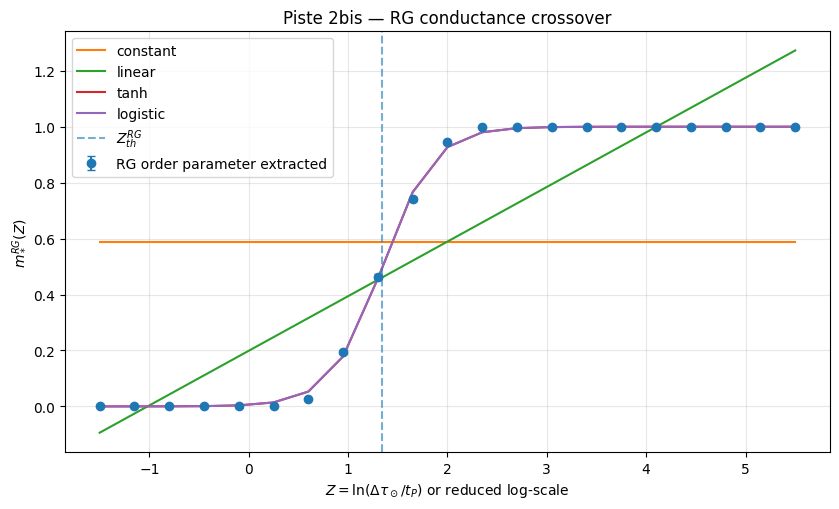

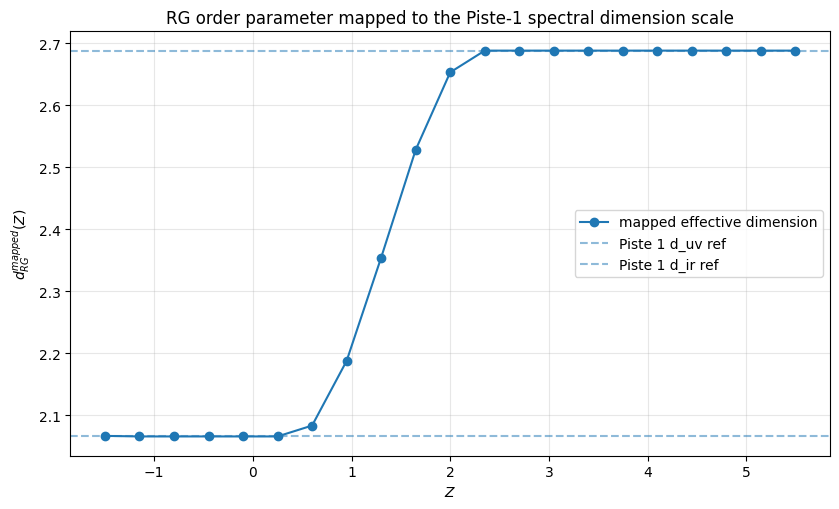

In [9]:
# ============================================================
# Cellule 9 — Figures du scan principal
# ============================================================
Z = profile['Z'].to_numpy(float)
fig, ax = plt.subplots(figsize=(8.5,5.2))
ax.errorbar(Z, profile['m_rg_fit'], yerr=profile['m_sem'].fillna(0), fmt='o', capsize=3, label='RG order parameter extracted')
for name, yhat in preds.items():
    ax.plot(Z, yhat, label=name)
ax.axvline(summary['Z_th_RG'], ls='--', alpha=0.6, label=r'$Z_{th}^{RG}$')
ax.set_xlabel(r'$Z=\ln(\Delta\tau_\odot/t_P)$ or reduced log-scale')
ax.set_ylabel(r'$m_*^{RG}(Z)$')
ax.set_title('Piste 2bis — RG conductance crossover')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(OUTDIR / 'piste2bis_main_rg_order_parameter.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8.5,5.2))
ax.plot(profile['Z'], profile['d_rg_mapped'], 'o-', label='mapped effective dimension')
ax.axhline(PISTE1['d_uv_mean'], ls='--', alpha=0.5, label='Piste 1 d_uv ref')
ax.axhline(PISTE1['d_ir_mean'], ls='--', alpha=0.5, label='Piste 1 d_ir ref')
ax.set_xlabel(r'$Z$')
ax.set_ylabel(r'$d_{RG}^{mapped}(Z)$')
ax.set_title('RG order parameter mapped to the Piste-1 spectral dimension scale')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(OUTDIR / 'piste2bis_main_mapped_dimension.png', dpi=180)
plt.show()


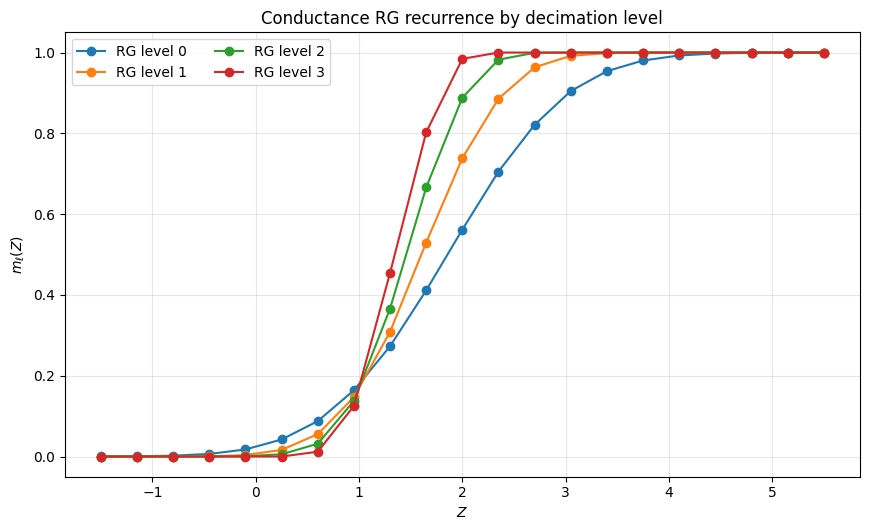

In [10]:
# ============================================================
# Cellule 10 — Visualisation de la récurrence RG niveau par niveau
# ============================================================
level_profile = raw.groupby(['rg_level','Z'])['m_active'].mean().reset_index()
fig, ax = plt.subplots(figsize=(8.8,5.4))
for level, sub in level_profile.groupby('rg_level'):
    ax.plot(sub['Z'], sub['m_active'], 'o-', label=f'RG level {level}')
ax.set_xlabel(r'$Z$')
ax.set_ylabel(r'$m_\ell(Z)$')
ax.set_title('Conductance RG recurrence by decimation level')
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()
fig.savefig(OUTDIR / 'piste2bis_rg_levels.png', dpi=180)
plt.show()


[rg:negative_no_vertical_N50] realization 1/50 done | rows=84 | elapsed=0.0s
[rg:negative_no_vertical_N50] realization 2/50 done | rows=168 | elapsed=0.1s
[rg:negative_no_vertical_N50] realization 3/50 done | rows=252 | elapsed=0.1s
[rg:negative_no_vertical_N50] realization 4/50 done | rows=336 | elapsed=0.2s
[rg:negative_no_vertical_N50] realization 5/50 done | rows=420 | elapsed=0.2s
[rg:negative_no_vertical_N50] realization 6/50 done | rows=504 | elapsed=0.2s
[rg:negative_no_vertical_N50] realization 7/50 done | rows=588 | elapsed=0.3s
[rg:negative_no_vertical_N50] realization 8/50 done | rows=672 | elapsed=0.3s
[rg:negative_no_vertical_N50] realization 9/50 done | rows=756 | elapsed=0.3s
[rg:negative_no_vertical_N50] realization 10/50 done | rows=840 | elapsed=0.4s
[rg:negative_no_vertical_N50] realization 11/50 done | rows=924 | elapsed=0.4s
[rg:negative_no_vertical_N50] realization 12/50 done | rows=1008 | elapsed=0.4s
[rg:negative_no_vertical_N50] realization 13/50 done | rows=1

,Z,m_rg,m_std,n,m_sem,m_rg_fit,d_rg_mapped
0,-1.50,0.0,0.0,50,0.0,0.0,2.066
1,-1.15,0.0,0.0,50,0.0,0.0,2.066
2,-0.80,0.0,0.0,50,0.0,0.0,2.066
3,-0.45,0.0,0.0,50,0.0,0.0,2.066
4,-0.10,0.0,0.0,50,0.0,0.0,2.066
5,0.25,0.0,0.0,50,0.0,0.0,2.066
6,0.60,0.0,0.0,50,0.0,0.0,2.066
7,0.95,0.0,0.0,50,0.0,0.0,2.066
8,1.30,0.0,0.0,50,0.0,0.0,2.066
9,1.65,0.0,0.0,50,0.0,0.0,2.066


,model,rss,aic,bic,k,params,error,delta_aic,delta_bic
0,constant,0.0,-14568.221057,-14567.176535,1,[0.0],None,0.0,0.000000
1,linear,0.0,-14566.221057,-14564.132012,2,"[0.0, 0.0]",None,2.0,3.044522
2,tanh,0.0,-14562.221057,-14558.042967,4,"[0.0, 0.0, -1.5, 1.1666666666666667]",None,6.0,9.133567
3,logistic,0.0,-14562.221057,-14558.042967,4,"[0.0, 0.0, -1.5, 1.1666666666666667]",None,6.0,9.133567


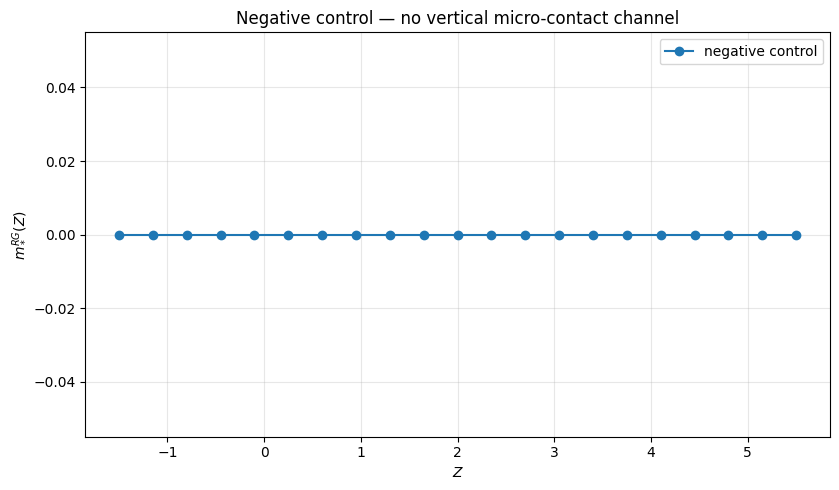

In [11]:
# ============================================================
# Cellule 11 — Contrôle négatif : aucun lien vertical actif
# ============================================================
neg_cfg = replace(main_cfg, theta_center=1e9, theta_jitter=0.0, hierarchical_noise=0.0, n_realizations=main_cfg.n_realizations)
neg_raw = run_rg_scan(neg_cfg, verbose=True, tag='negative_no_vertical_N50', resume=True, checkpoint_every=1)
neg_profile = aggregate_rg_scan(neg_raw, neg_cfg)
neg_summary, neg_fit_df, neg_preds = extract_rg_parameters(neg_profile, neg_cfg)

print('Negative control summary:')
print(json.dumps(neg_summary, indent=2))
display(neg_profile)
display(neg_fit_df)

neg_raw.to_csv(OUTDIR / 'piste2bis_negative_raw.csv', index=False)
neg_profile.to_csv(OUTDIR / 'piste2bis_negative_profile.csv', index=False)
neg_fit_df.to_csv(OUTDIR / 'piste2bis_negative_fit_models.csv', index=False)
with open(OUTDIR / 'piste2bis_negative_summary.json', 'w') as f:
    json.dump(neg_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8.5,5.0))
ax.plot(neg_profile['Z'], neg_profile['m_rg_fit'], 'o-', label='negative control')
ax.set_xlabel(r'$Z$')
ax.set_ylabel(r'$m_*^{RG}(Z)$')
ax.set_title('Negative control — no vertical micro-contact channel')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(OUTDIR / 'piste2bis_negative_control.png', dpi=180)
plt.show()


In [12]:

# ============================================================
# Cellule 12 — Sweep de robustesse RG avec reprise checkpoint
# ============================================================
def run_variant(tag, cfg_variant):
    print('\n' + '='*72)
    print('[variant]', tag)
    t0 = time.time()
    raw_v = run_rg_scan(cfg_variant, verbose=True, tag=f'variant_{tag}', resume=True, checkpoint_every=1)
    prof_v = aggregate_rg_scan(raw_v, cfg_variant)
    summ_v, fit_v, preds_v = extract_rg_parameters(prof_v, cfg_variant)
    summ_v.update({'tag': tag, 'elapsed_s': time.time()-t0, **asdict(cfg_variant)})
    raw_v.to_csv(OUTDIR / f'{tag}_raw.csv', index=False)
    prof_v.to_csv(OUTDIR / f'{tag}_profile.csv', index=False)
    fit_v.to_csv(OUTDIR / f'{tag}_fit_models.csv', index=False)
    with open(OUTDIR / f'{tag}_summary.json', 'w', encoding='utf-8') as f:
        json.dump(summ_v, f, indent=2, ensure_ascii=False)
    print(json.dumps({k:summ_v[k] for k in ['best_sigmoid_model','delta_aic_constant_vs_sigmoid','delta_aic_linear_vs_sigmoid','Z_th_RG','Delta_Z_RG','kappa_over_a_RG']}, indent=2))
    return summ_v, prof_v, fit_v

# Les variantes conservent n_realizations=50 par défaut, conformément à la version publication.
variants = [
    ('base', main_cfg),
    ('cutoff_0p40', replace(main_cfg, activation_cutoff=0.40, random_seed=main_cfg.random_seed+100)),
    ('cutoff_0p60', replace(main_cfg, activation_cutoff=0.60, random_seed=main_cfg.random_seed+200)),
    ('jitter_low', replace(main_cfg, theta_jitter=0.65, random_seed=main_cfg.random_seed+300)),
    ('jitter_high', replace(main_cfg, theta_jitter=1.05, random_seed=main_cfg.random_seed+400)),
]
if RUN_PUBLICATION_SWEEP:
    variants += [
        ('L64_layers8', replace(main_cfg, L=64, n_realizations=main_cfg.n_realizations, random_seed=main_cfg.random_seed+500)),
        ('layers12', replace(main_cfg, layers=12, n_realizations=main_cfg.n_realizations, random_seed=main_cfg.random_seed+600)),
        ('wide_grid', replace(main_cfg, z_min=-2.0, z_max=6.0, n_z=33, n_realizations=main_cfg.n_realizations, random_seed=main_cfg.random_seed+700)),
    ]

summaries, profiles = [], {}
for tag, cv in variants:
    s, p, f = run_variant(tag, cv)
    summaries.append(s)
    profiles[tag] = p

robust_df = pd.DataFrame(summaries)
robust_df.to_csv(OUTDIR / 'piste2bis_robustness_summary.csv', index=False)
display(robust_df[['tag','best_sigmoid_model','delta_aic_constant_vs_sigmoid','delta_aic_linear_vs_sigmoid','Z_th_RG','Delta_Z_RG','kappa_over_a_RG','tau_c_seconds_if_Z_is_physical']])



[variant] base
[rg:variant_base] realization 1/50 done | rows=84 | elapsed=0.0s
[rg:variant_base] realization 2/50 done | rows=168 | elapsed=0.1s
[rg:variant_base] realization 3/50 done | rows=252 | elapsed=0.1s
[rg:variant_base] realization 4/50 done | rows=336 | elapsed=0.1s
[rg:variant_base] realization 5/50 done | rows=420 | elapsed=0.2s
[rg:variant_base] realization 6/50 done | rows=504 | elapsed=0.2s
[rg:variant_base] realization 7/50 done | rows=588 | elapsed=0.2s
[rg:variant_base] realization 8/50 done | rows=672 | elapsed=0.3s
[rg:variant_base] realization 9/50 done | rows=756 | elapsed=0.3s
[rg:variant_base] realization 10/50 done | rows=840 | elapsed=0.4s
[rg:variant_base] realization 11/50 done | rows=924 | elapsed=0.4s
[rg:variant_base] realization 12/50 done | rows=1008 | elapsed=0.4s
[rg:variant_base] realization 13/50 done | rows=1092 | elapsed=0.5s
[rg:variant_base] realization 14/50 done | rows=1176 | elapsed=0.5s
[rg:variant_base] realization 15/50 done | rows=1260 

,tag,best_sigmoid_model,delta_aic_constant_vs_sigmoid,delta_aic_linear_vs_sigmoid,Z_th_RG,Delta_Z_RG,kappa_over_a_RG,tau_c_seconds_if_Z_is_physical
0,base,tanh,151.743686,118.140078,1.344013,0.516048,0.133153,2.067220e-43
1,cutoff_0p40,tanh,151.651523,118.076735,1.335786,0.518005,0.134165,2.050282e-43
2,cutoff_0p60,logistic,152.038460,116.563078,2.367591,0.512472,0.131314,5.753354e-43
3,jitter_low,tanh,148.210045,114.266377,1.436832,0.498652,0.124327,2.268283e-43
4,jitter_high,logistic,150.601893,117.757726,1.219690,0.536881,0.144121,1.825551e-43
5,L64_layers8,tanh,151.834215,117.371073,1.361657,0.555392,0.154230,2.104018e-43
6,layers12,tanh,151.181292,117.659137,1.337772,0.514215,0.132209,2.054359e-43
7,wide_grid,tanh,265.886136,214.631744,1.327752,0.441751,0.097572,2.033877e-43


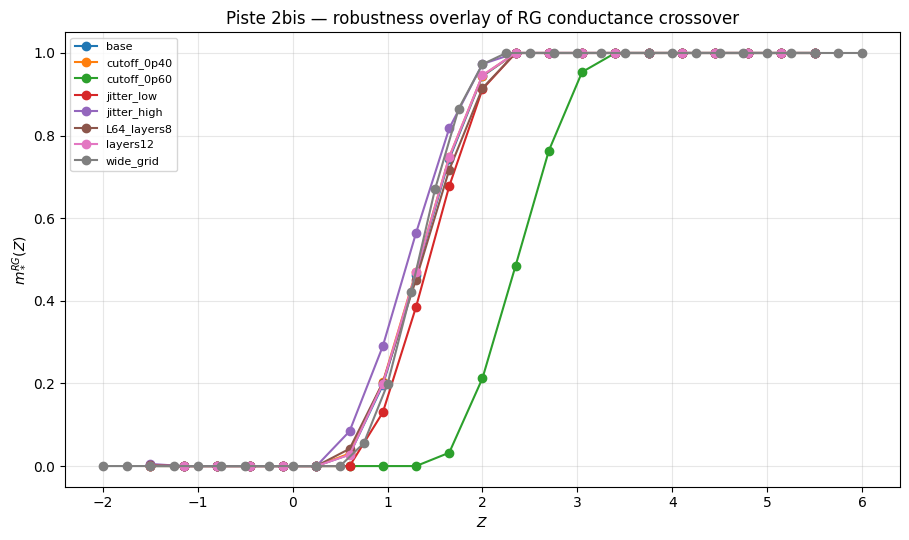

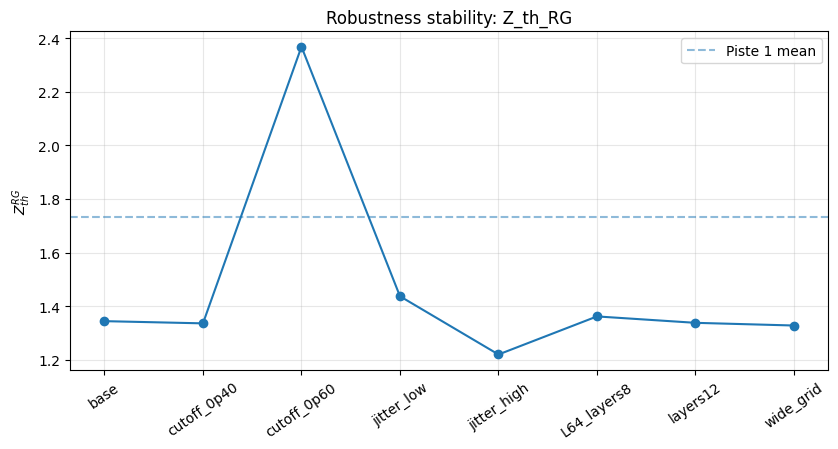

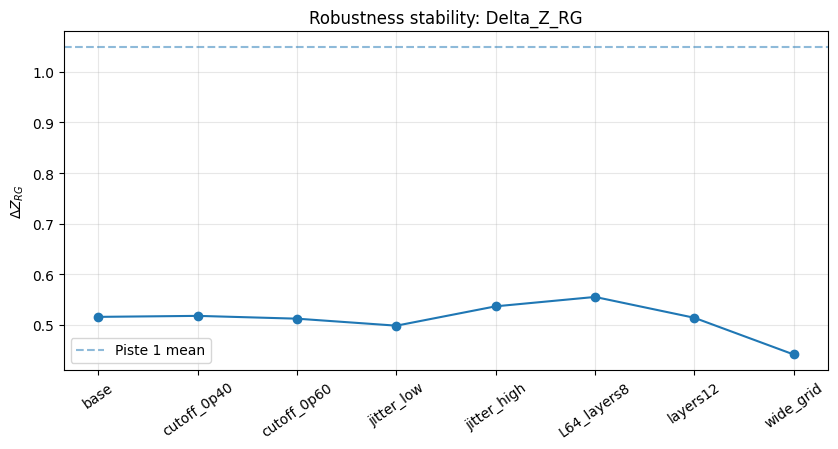

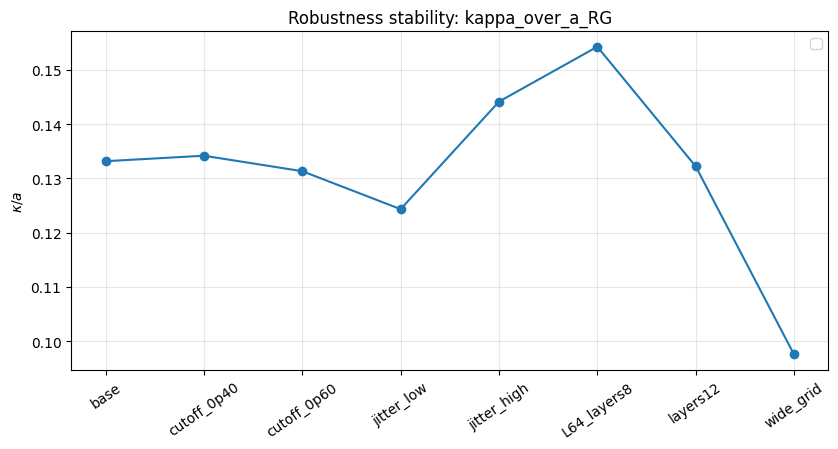

In [13]:
# ============================================================
# Cellule 13 — Figures de robustesse
# ============================================================
fig, ax = plt.subplots(figsize=(9.2,5.5))
for tag, prof in profiles.items():
    ax.plot(prof['Z'], prof['m_rg_fit'], 'o-', label=tag)
ax.set_xlabel(r'$Z$')
ax.set_ylabel(r'$m_*^{RG}(Z)$')
ax.set_title('Piste 2bis — robustness overlay of RG conductance crossover')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(OUTDIR / 'piste2bis_robustness_overlay.png', dpi=180)
plt.show()

for col, ylabel in [('Z_th_RG', r'$Z_{th}^{RG}$'), ('Delta_Z_RG', r'$\Delta Z_{RG}$'), ('kappa_over_a_RG', r'$\kappa/a$')]:
    fig, ax = plt.subplots(figsize=(8.5,4.6))
    ax.plot(robust_df['tag'], robust_df[col], 'o-')
    if col == 'Z_th_RG':
        ax.axhline(PISTE1['Z_th_mean'], ls='--', alpha=0.5, label='Piste 1 mean')
    if col == 'Delta_Z_RG':
        ax.axhline(PISTE1['Delta_Z_mean'], ls='--', alpha=0.5, label='Piste 1 mean')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Robustness stability: {col}')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=35)
    ax.legend()
    plt.tight_layout()
    fig.savefig(OUTDIR / f'piste2bis_robustness_{col}.png', dpi=180)
    plt.show()


In [14]:
# ============================================================
# Cellule 14 — Synthèse automatique reviewer-safe
# ============================================================
rg_review = {
    'n_variants': int(len(robust_df)),
    'fraction_sigmoid_AIC_vs_constant_delta_gt_10': float((robust_df['delta_aic_constant_vs_sigmoid'] > 10).mean()),
    'fraction_sigmoid_AIC_vs_linear_delta_gt_6': float((robust_df['delta_aic_linear_vs_sigmoid'] > 6).mean()),
    'Z_th_RG_mean': float(robust_df['Z_th_RG'].mean()),
    'Z_th_RG_std': float(robust_df['Z_th_RG'].std(ddof=1)),
    'Delta_Z_RG_mean': float(robust_df['Delta_Z_RG'].mean()),
    'Delta_Z_RG_std': float(robust_df['Delta_Z_RG'].std(ddof=1)),
    'kappa_over_a_RG_mean': float(robust_df['kappa_over_a_RG'].mean()),
    'kappa_over_a_RG_std': float(robust_df['kappa_over_a_RG'].std(ddof=1)),
    'tau_c_seconds_mean': float(robust_df['tau_c_seconds_if_Z_is_physical'].mean()),
    'tau_c_seconds_std': float(robust_df['tau_c_seconds_if_Z_is_physical'].std(ddof=1)),
}
rg_review['reviewer_safe_minimum'] = bool(
    rg_review['fraction_sigmoid_AIC_vs_constant_delta_gt_10'] >= 0.8 and
    rg_review['fraction_sigmoid_AIC_vs_linear_delta_gt_6'] >= 0.8 and
    np.isfinite(rg_review['Z_th_RG_mean']) and
    np.isfinite(rg_review['Delta_Z_RG_mean']) and
    rg_review['Delta_Z_RG_mean'] > 0
)
with open(OUTDIR / 'piste2bis_reviewer_safe_summary.json', 'w') as f:
    json.dump(rg_review, f, indent=2)
print(json.dumps(rg_review, indent=2))


{
  "n_variants": 8,
  "fraction_sigmoid_AIC_vs_constant_delta_gt_10": 1.0,
  "fraction_sigmoid_AIC_vs_linear_delta_gt_6": 1.0,
  "Z_th_RG_mean": 1.4663867880293555,
  "Z_th_RG_std": 0.36891031673128194,
  "Delta_Z_RG_mean": 0.5116771981586336,
  "Delta_Z_RG_std": 0.033105290289423814,
  "kappa_over_a_RG_mean": 0.13138626016498658,
  "kappa_over_a_RG_std": 0.016426284893564163,
  "tau_c_seconds_mean": 2.5196181728948447e-43,
  "tau_c_seconds_std": 1.312142182067782e-43,
  "reviewer_safe_minimum": true
}


In [15]:
# ============================================================
# Cellule 15 — Autotests
# ============================================================
assert np.isfinite(summary['Z_th_RG']), 'Z_th_RG is not finite.'
assert np.isfinite(summary['Delta_Z_RG']), 'Delta_Z_RG is not finite.'
assert summary['Delta_Z_RG'] > 0, 'Delta_Z_RG must be positive.'
assert np.isfinite(summary['kappa_over_a_RG']), 'kappa/a is not finite.'
assert summary['kappa_over_a_RG'] > 0, 'kappa/a must be positive.'
assert summary['delta_aic_constant_vs_sigmoid'] > 10, 'Sigmoid not sufficiently preferred over constant.'
assert summary['delta_aic_linear_vs_sigmoid'] > 6, 'Sigmoid not sufficiently preferred over linear.'
assert float(neg_profile['m_rg_fit'].max()) < 1e-9, 'Negative control produced active vertical conductances.'
assert rg_review['reviewer_safe_minimum'] is True, 'Robustness sweep did not pass reviewer-safe minimum.'
assert abs(summary['kappa_over_a_RG'] - 0.5 * summary['Delta_Z_RG']**2) < 1e-10, 'kappa/a relation mismatch.'
print('Autotests completed. Reviewer-safe status:', rg_review['reviewer_safe_minimum'])


Autotests completed. Reviewer-safe status: True


## Formulation reviewer-safe suggérée

> We construct a minimal decimation-RG model for the effective conductances of a controlled cell-4 multiplex substrate. Local inter-layer micro-contacts are represented by hard activation thresholds, while the RG step aggregates conductances over \(2\times2\) cell blocks and applies a majority-like effective activation rule. The resulting RG order parameter \(m_*^{RG}(Z)\) exhibits a sigmoidal crossover, statistically preferred over constant and linear alternatives. The extracted parameters \(Z_{th}^{RG}\), \(\Delta Z_{RG}\), and \(\kappa/a=\Delta Z_{RG}^2/2\) provide an operational bridge between the numerical spectral crossover of Piste 1 and the Allen–Cahn mean-field closure of Piste 2. This does not yet amount to a full microscopic derivation from the IFS alone, but it removes one layer of phenomenological freedom by deriving the front parameters from an explicit conductance-renormalization rule.

En français :

> Nous construisons un modèle minimal de décimation RG des conductances effectives du substrat cell-4 multiplex. Les micro-contacts inter-couches sont représentés par des seuils locaux d’activation, puis une étape RG agrège les conductances sur des blocs \(2\times2\) et applique une règle effective de majorité. Le paramètre d’ordre RG obtenu \(m_*^{RG}(Z)\) présente un crossover sigmoïde statistiquement préféré aux modèles constant et linéaire. Les paramètres extraits \(Z_{th}^{RG}\), \(\Delta Z_{RG}\) et \(\kappa/a=\Delta Z_{RG}^2/2\) établissent un pont opérationnel entre le crossover spectral numérique de la Piste 1 et la fermeture mean-field Allen–Cahn de la Piste 2. Ce résultat ne constitue pas encore une dérivation microphysique complète depuis l’IFS seul, mais il réduit le degré de liberté phénoménologique en faisant émerger les paramètres du front depuis une règle explicite de renormalisation des conductances.


## Export ZIP des fichiers de sortie

Cette cellule regroupe tous les exports produits dans `OUTDIR` et crée une archive téléchargeable depuis Colab. À exécuter après les autotests et les figures.


In [16]:

# ============================================================
# Cellule 16 — Export ZIP final + persistance Drive
# ZIP_EXPORT_CELL_PISTE2BIS_CHECKPOINT_DRIVE
# ============================================================
from pathlib import Path
import zipfile, json, time, os, shutil

OUTDIR = Path(OUTDIR)
OUTDIR.mkdir(parents=True, exist_ok=True)

# Si OUTDIR est dans Drive, le ZIP sera aussi persistant dans Drive.
ZIP_PATH = OUTDIR.parent / f'{OUTDIR.name}_outputs.zip'
MANIFEST_PATH = OUTDIR / 'ZIP_MANIFEST.json'

manifest = {
    'created_at_unix': time.time(),
    'outdir': str(OUTDIR),
    'zip_path': str(ZIP_PATH),
    'drive_available': bool(DRIVE_AVAILABLE),
    'checkpoint_dir': str(CHECKPOINT_DIR),
    'run_fast': bool(RUN_FAST),
    'run_publication_sweep': bool(RUN_PUBLICATION_SWEEP),
    'files': []
}

for file_path in sorted(OUTDIR.rglob('*')):
    if file_path.is_file():
        try:
            size_bytes = file_path.stat().st_size
        except OSError:
            size_bytes = None
        manifest['files'].append({
            'relative_path': str(file_path.relative_to(OUTDIR)),
            'size_bytes': size_bytes
        })

with open(MANIFEST_PATH, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, mode='w', compression=zipfile.ZIP_DEFLATED) as zf:
    for file_path in sorted(OUTDIR.rglob('*')):
        if file_path.is_file():
            arcname = Path(OUTDIR.name) / file_path.relative_to(OUTDIR)
            zf.write(file_path, arcname=str(arcname))

zip_size_mb = ZIP_PATH.stat().st_size / (1024**2)
print(f'ZIP created: {ZIP_PATH}')
print(f'ZIP size: {zip_size_mb:.3f} MB')
print(f'Files included: {len(manifest["files"])}')
print('Persistent in Google Drive:', DRIVE_AVAILABLE)

for item in manifest['files'][:30]:
    print(' -', item['relative_path'], f"({item['size_bytes']} bytes)")
if len(manifest['files']) > 30:
    print(f' ... +{len(manifest["files"]) - 30} more files')

# Téléchargement direct si exécuté dans Google Colab.
try:
    from google.colab import files
    files.download(str(ZIP_PATH))
except Exception as exc:
    print('Automatic Colab download unavailable in this environment.')
    print('Download manually from:', ZIP_PATH)


ZIP created: /content/drive/MyDrive/ROSG_exports/piste2bis_rg_conductances_cell4_N50_outputs.zip
ZIP size: 0.939 MB
Files included: 82
Persistent in Google Drive: True
 - L64_layers8_fit_models.csv (695 bytes)
 - L64_layers8_profile.csv (1499 bytes)
 - L64_layers8_raw.csv (124516 bytes)
 - L64_layers8_summary.json (1169 bytes)
 - RUN_METADATA.json (318 bytes)
 - _checkpoints/main_N50_abe6a6ecc45b_DONE.txt (10 bytes)
 - _checkpoints/main_N50_abe6a6ecc45b_checkpoint_meta.json (1241 bytes)
 - _checkpoints/main_N50_abe6a6ecc45b_raw_partial.csv (109500 bytes)
 - _checkpoints/negative_no_vertical_N50_bc9e5d065d3b_DONE.txt (10 bytes)
 - _checkpoints/negative_no_vertical_N50_bc9e5d065d3b_checkpoint_meta.json (1295 bytes)
 - _checkpoints/negative_no_vertical_N50_bc9e5d065d3b_raw_partial.csv (95250 bytes)
 - _checkpoints/variant_L64_layers8_52accf11042c_DONE.txt (10 bytes)
 - _checkpoints/variant_L64_layers8_52accf11042c_checkpoint_meta.json (1274 bytes)
 - _checkpoints/variant_L64_layers8_52acc

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>